# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  state_neuron = []
  for i in range(len(X1)):
    total = X1[i] + X2[i]
    if total >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2
result = MCP_Neurons_AND(X1, X2, T)
print("Output of AND gate for inputs", X1, "and", X2, "with threshold", T, ":", result)

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2 : [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)

print("Output of OR gate for inputs", X1, "and", X2, "with threshold", T, ":", result_or)

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1 : [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Workshop3/mnist_0_and_1.csv")

X = df_0_1.drop("label", axis=1).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

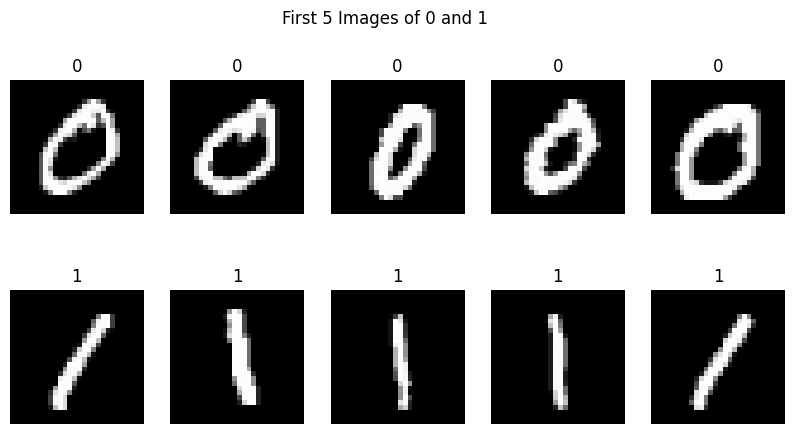

In [ ]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) >= 5 and len(images_1) >= 5:
    for i in range(5):
        axes[0][i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0][i].set_title("0")
        axes[0][i].axis("off")

        axes[1][i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1][i].set_title("1")
        axes[1][i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1")
    plt.show()
else:
    print("Not enough images to display")

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data)
    - y: Labels (true output)
    - weights: Initial weights
    - bias: Initial bias
    - learning_rate: Learning rate
    - epochs: Number of iterations

    Returns:
    - weights: Updated weights
    - bias: Updated bias
    - accuracy: Final accuracy
    """
    n_samples = len(X)
    accuracy = 0

    for epoch in range(epochs):
        correct = 0

        for i in range(n_samples):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                error = y[i] - y_pred
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
            else:
                correct += 1

        accuracy = correct / n_samples

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print("Epoch", epoch + 1, ": Accuracy =", round(accuracy, 4))

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [26]:
predictions = np.dot(X, weights) + bias
y_pred = []

for p in predictions:
    if p >= 0:
        y_pred.append(1)
    else:
        y_pred.append(0)
y_pred = np.array(y_pred)
final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", round(final_accuracy, 4))

misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for i in range(min(10, len(misclassified_idx))):
        idx = misclassified_idx[i]
        ax = axes.flat[i]

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title("Pred: " + str(y_pred[idx]) + ", True: " + str(y[idx]))
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0
All images were correctly classified!


# Perceptron Algorithm for 3 vs 5 Classification.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Workshop3/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)


print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
